
# We will work with a recurrent neural network RNN. These are designed to learn sequential data, such as names.

In [82]:
# import libraries
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

## 1. Read and prepare training data

In [83]:
# read train data set
train = pd.read_parquet("../data/gold/model/mane_gender_encoded_train.parquet")
train.info()

X_train = train['name_encoded']
Y_train = train['gender_encoded']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468909 entries, 0 to 468908
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   name_encoded    468909 non-null  object
 1   gender_encoded  468909 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 7.2+ MB


In [84]:
# read validation data set
val = pd.read_parquet("../data/gold/model/mane_gender_encoded_val.parquet")
val.info()

X_val = val['name_encoded']
Y_val = val['gender_encoded']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156303 entries, 0 to 156302
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   name_encoded    156303 non-null  object
 1   gender_encoded  156303 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB


In [85]:
# read test data set
test = pd.read_parquet("../data/gold/model/mane_gender_encoded_test.parquet")
test.info()

X_test = test['name_encoded']
Y_test = test['gender_encoded']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156304 entries, 0 to 156303
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   name_encoded    156304 non-null  object
 1   gender_encoded  156304 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB


## 2. Define Recurent Neural Network

In [86]:
# Basic config
vocab_size = 30 
embedding_dim = 16 
maxlen = 15

In [87]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

c:\Users\Hugo\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [88]:
X_train = np.vstack(X_train).astype(np.int32)
X_val = np.vstack(X_val).astype(np.int32)
X_test = np.vstack(X_test).astype(np.int32)

In [89]:
#  Define an early stopping to avoind overfiting
from tensorflow.keras.callbacks import EarlyStopping

callback_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [90]:
history = model.fit(
    X_train, Y_train,
    epochs=10,              
    batch_size=32,          
    validation_data=(X_val, Y_val),
    callbacks=[callback_early_stop]
)

Epoch 1/10
14654/14654 ━━━━━━━━━━━━━━━━━━━━ 106s 7ms/step - accuracy: 0.8161 - loss: 0.4020 - val_accuracy: 0.8402 - val_loss: 0.3564
Epoch 2/10
14654/14654 ━━━━━━━━━━━━━━━━━━━━ 99s 7ms/step - accuracy: 0.8477 - loss: 0.3433 - val_accuracy: 0.8547 - val_loss: 0.3302
Epoch 3/10
14654/14654 ━━━━━━━━━━━━━━━━━━━━ 88s 6ms/step - accuracy: 0.8581 - loss: 0.3231 - val_accuracy: 0.8584 - val_loss: 0.3203
Epoch 4/10
14654/14654 ━━━━━━━━━━━━━━━━━━━━ 89s 6ms/step - accuracy: 0.8629 - loss: 0.3125 - val_accuracy: 0.8636 - val_loss: 0.3120
Epoch 5/10
14654/14654 ━━━━━━━━━━━━━━━━━━━━ 89s 6ms/step - accuracy: 0.8661 - loss: 0.3057 - val_accuracy: 0.8640 - val_loss: 0.3106
Epoch 6/10
14654/14654 ━━━━━━━━━━━━━━━━━━━━ 88s 6ms/step - accuracy: 0.8688 - loss: 0.2999 - val_accuracy: 0.8659 - val_loss: 0.3053
Epoch 7/10
14654/14654 ━━━━━━━━━━━━━━━━━━━━ 88s 6ms/step - accuracy: 0.8705 - loss: 0.2957 - val_accuracy: 0.8664 - val_loss: 0.3040
Epoch 8/10
14654/14654 ━━━━━━━━━━━━━━━━━━━━ 88s 6ms/step - accuracy:

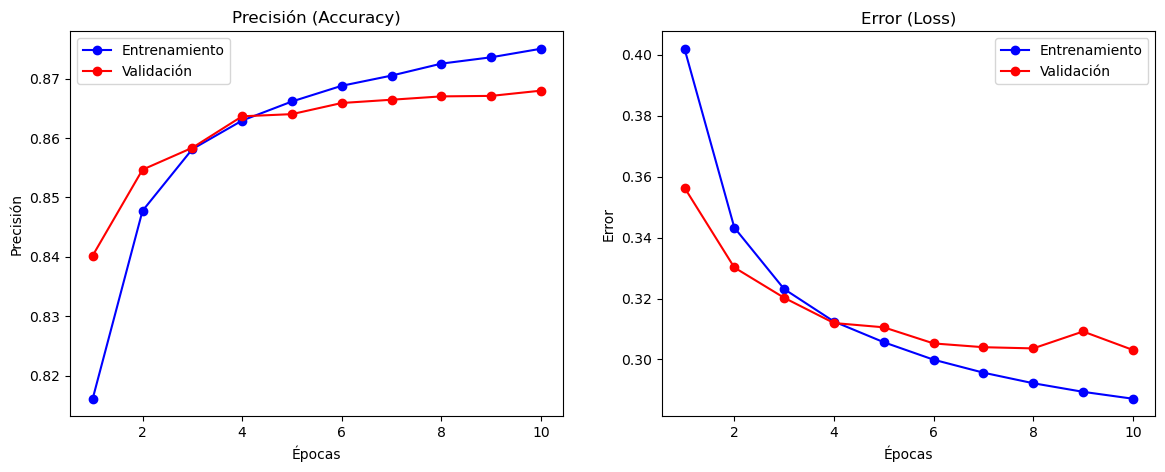

In [91]:
import matplotlib.pyplot as plt

# Extract data from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Entrenamiento')
plt.plot(epochs, val_acc, 'ro-', label='Validación')
plt.title('Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Error (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Entrenamiento')
plt.plot(epochs, val_loss, 'ro-', label='Validación')
plt.title('Error (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Error')
plt.legend()

plt.show()

## 3. Model validation

In [92]:
# model trained evaluation with test data

test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f"Precisión en el conjunto de Test: {test_acc:.2%}")

4885/4885 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.8686 - loss: 0.3006
Precisión en el conjunto de Test: 86.86%


In [93]:
# Get probabilities (0 - 1)
y_pred_probs = model.predict(X_test)

# Convet to binary
y_pred_clases = (y_pred_probs > 0.5).astype(int)

4885/4885 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


In [94]:
# We creatre a dataframe with validation info

df_test_results = pd.DataFrame({
    'Real': Y_test,
    'Predicted': y_pred_clases.flatten(),
    'Probability': y_pred_probs.flatten()
})

# Filter ionly errors
errores = df_test_results[df_test_results['Real'] != df_test_results['Predicted']]
print(errores.head(10))

    Real  Predicted  Probability
4      0          1     0.822472
12     1          0     0.320633
36     0          1     0.784091
41     0          1     0.783736
44     1          0     0.180632
46     1          0     0.177892
61     0          1     0.968930
81     0          1     0.514328
84     0          1     0.977716
91     0          1     0.611054


In [95]:
errores

,Real,Predicted,Probability
4,0,1,0.822472
12,1,0,0.320633
36,0,1,0.784091
41,0,1,0.783736
44,1,0,0.180632
...,...,...,...
156270,0,1,0.621658
156283,1,0,0.096042
156288,1,0,0.359483
156300,1,0,0.454720


In [96]:
df_test_results

,Real,Predicted,Probability
0,0,0,0.213682
1,1,1,0.996417
2,1,1,0.985529
3,0,0,0.054729
4,0,1,0.822472
...,...,...,...
156299,0,0,0.049371
156300,1,0,0.454720
156301,0,0,0.001758
156302,0,1,0.810325


In [97]:
# Error percentage of the total of records
(errores['Real'].count() * 100) / df_test_results['Real'].count()


np.float64(13.138499334629952)

## 4. Test with a real data set

In [108]:
# Define a list of common names on LATAM
names_latam = [
    "Juan", "Maria", "Carlos", "Ana", "Jose", "Laura", "Luis", "Sofia", 
    "Pedro", "Elena", "Diego", "Lucia", "Miguel", "Isabel", "Javier", 
    "Camila", "Andres", "Valentina", "Fernando", "Mariana", "Alejandro", 
    "Daniela", "Ricardo", "Gabriela", "Hugo", "Paula", "Sebastian", "Natalia",
    "Santiago", "Ximena"
]

data = [
    {"name": "Juan", "gender": "M"},
    {"name": "Maria", "gender": "F"},
    {"name": "Carlos", "gender": "M"},
    {"name": "Ana", "gender": "F"},
    {"name": "Jose", "gender": "M"},
    {"name": "Laura", "gender": "F"},
    {"name": "Luis", "gender": "M"},
    {"name": "Sofia", "gender": "F"},
    {"name": "Pedro", "gender": "M"},
    {"name": "Elena", "gender": "F"},
    {"name": "Diego", "gender": "M"},
    {"name": "Lucia", "gender": "F"},
    {"name": "Miguel", "gender": "M"},
    {"name": "Isabel", "gender": "F"},
    {"name": "Javier", "gender": "M"},
    {"name": "Camila", "gender": "F"},
    {"name": "Andres", "gender": "M"},
    {"name": "Valentina", "gender": "F"},
    {"name": "Fernando", "gender": "M"},
    {"name": "Mariana", "gender": "F"},
    {"name": "Alejandro", "gender": "M"},
    {"name": "Daniela", "gender": "F"},
    {"name": "Ricardo", "gender": "M"},
    {"name": "Gabriela", "gender": "F"},
    {"name": "Hugo", "gender": "M"},
    {"name": "Paula", "gender": "F"},
    {"name": "Sebastian", "gender": "M"},
    {"name": "Natalia", "gender": "F"},
    {"name": "Santiago", "gender": "M"},
    {"name": "Ximena", "gender": "F"}
]

names_latam = pd.DataFrame(data)
names_latam.head(3)

,name,gender
0,Juan,M
1,Maria,F
2,Carlos,M


In [99]:
# Processing encode
import pickle

with open('../data/gold/model/names_encoder.pkl','rb') as f:
    tokenizer = pickle.load(f)

In [109]:
# enconde processing
from tensorflow.keras.preprocessing.sequence import pad_sequences

secuences = tokenizer.texts_to_sequences([n.lower() for n in names_latam['name']])
data_padded = pad_sequences(secuences, maxlen=15)
data_padded

array([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 17, 14,  1,  5],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 12,  1,  4,  2,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 13,  1,  4,  6,  7,  9],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  5,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 17,  7,  9,  3],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  6,  1, 14,  4,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  6, 14,  2,  9],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  9,  7, 21,  2,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 23,  3, 10,  4,  7],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  3,  6,  3,  5,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 10,  2,  3, 18,  7],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  6, 14, 13,  2,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 12,  2, 18, 14,  3,  6],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  2,  9,  1, 19,  3,  6],
       [ 0,  0,  0,  0,  0,  0,  0

In [110]:
prediction = model.predict(data_padded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [111]:
# Decode

reverse_word_map = {v: k for k, v in tokenizer.word_index.items()}

decoded_names = []
for sec in secuences:
    word = "".join([reverse_word_map.get(num, "") for num in sec if num != 0])
    decoded_names.append(word)

decoded_names

['juan',
 'maria',
 'carlos',
 'ana',
 'jose',
 'laura',
 'luis',
 'sofia',
 'pedro',
 'elena',
 'diego',
 'lucia',
 'miguel',
 'isabel',
 'javier',
 'camila',
 'andres',
 'valentina',
 'fernando',
 'mariana',
 'alejandro',
 'daniela',
 'ricardo',
 'gabriela',
 'hugo',
 'paula',
 'sebastian',
 'natalia',
 'santiago',
 'ximena']

In [115]:
df_results_real_test = pd.DataFrame({
    "names" : names_latam['name'],
    "gender" : names_latam['gender'],
    "decoded" : decoded_names,
    "prediction" : prediction.flatten()
})

df_results_real_test['prediction'] = df_results_real_test["prediction"].apply(
    lambda x : "Hombre" if x > 0.5 else "Mujer"
)
df_results_real_test['gender'] = df_results_real_test['gender'].apply(
    lambda x : "Hombre" if x == "M" else "Mujer"
)

df_results_real_test.head(5)

,names,gender,decoded,prediction
0,Juan,Hombre,juan,Hombre
1,Maria,Mujer,maria,Hombre
2,Carlos,Hombre,carlos,Hombre
3,Ana,Mujer,ana,Mujer
4,Jose,Hombre,jose,Hombre


In [ ]:
# percentaje of accuracy
df = df_results_real_test.copy()

df['accuracy'] = df['gender'] == df['prediction']

predict_accuracy = df['accuracy'].mean() * 100

print(f'The prediction accuracy of RNN is {predict_accuracy:.2f}%')

The prediction of RNN is 83.33%
